In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pingouin as pg

In [2]:
df = pd.read_csv("morphing.csv")

In [3]:
sessions = df["session_uuid"].unique()
sessions

<StringArray>
['696cfac7-4b3e-4701-8229-cada9a2f3f56',
 '94359fbd-8eee-4ac6-af4a-a0e3fff5c48e',
 'a6fcb532-5695-48e9-8ce1-6d9a0795faeb',
 '2972da2a-7403-4a25-8825-c93f4631bbf8',
 '18643d68-5fb8-4606-9e27-1632cdbdf8f4',
 'be207b14-f65a-4609-acac-7142b5b1b443',
 '6b980f92-d2c6-404e-bf27-964e3a3b63ce',
 '57945201-861a-46ee-ba6e-a2ce7832bcdd',
 '9a1a9bf1-8450-4bbb-87ac-470f8906c853',
 '3d1b1edf-ab1b-45c9-a7b2-1c4a842f085c',
 '8f5acd6c-2536-4a43-9a37-1bb248d5f571',
 'ec69a24a-e37e-4380-b937-1cd1c0aafef4',
 '3556dfdf-fa41-4239-8058-7009833c9e33',
 'd8310ea2-d7d9-49d9-9e40-affc3f8a261a']
Length: 14, dtype: str

In [4]:
df = df[df['session_uuid'] != "9a1a9bf1-8450-4bbb-87ac-470f8906c853"] # All ratings at 100

In [5]:
df["pair"] = df["trial_id"].apply(lambda x: "->".join(x.split("_")[2:4]))
df["method"] = df["trial_id"].apply(lambda x: x.split("_")[1])
df["unordered_pair"] = df["pair"].apply(lambda x: "-".join(sorted(x.split("->"))))

# MOS

In [6]:
df_mos = df[df["rating_stimulus"] == "MOS"][["pair", "method", "unordered_pair", "session_uuid", "trial_id", "rating_score"]].drop_duplicates()

In [7]:
df_mos["method"].unique()

<StringArray>
['weights', 'outputs']
Length: 2, dtype: str

In [8]:
df_mos["pair"].unique()

<StringArray>
['tpt->vn', 'vn->fl', 'fl->vn', 'tpt->fl', 'fl->tpt', 'vn->tpt']
Length: 6, dtype: str

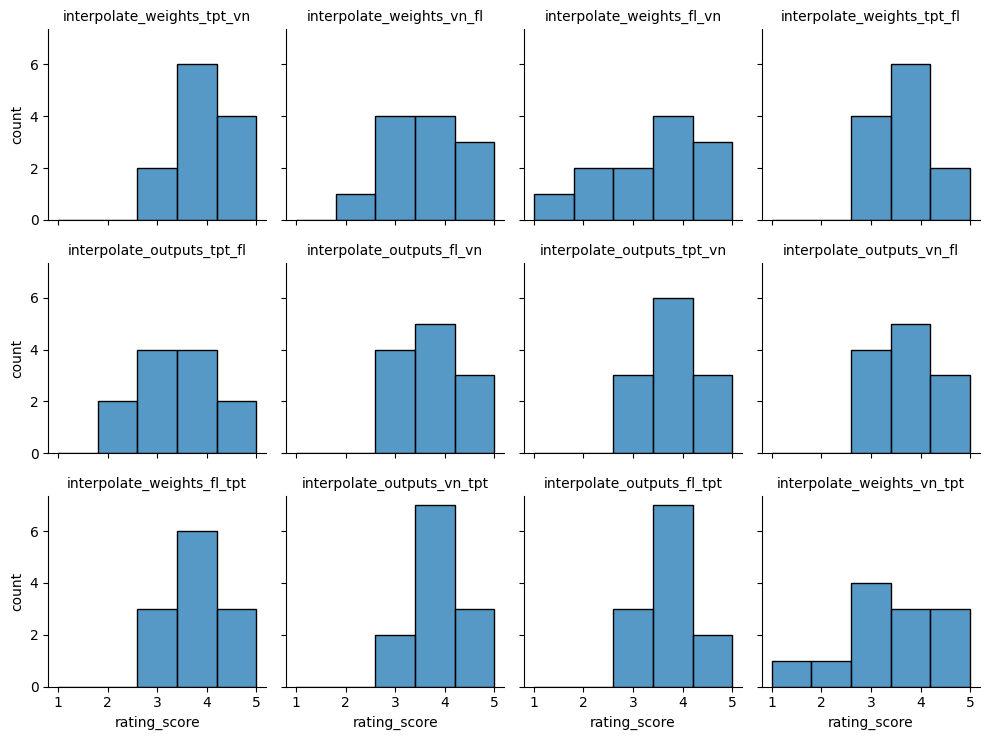

In [9]:
g = sns.displot(
    data=df_mos,
    x="rating_score",
    col="trial_id",
    col_wrap=4,
    kind="hist",
    bins=len(df_mos["rating_score"].unique()),
    height=2.5,
    aspect=1.0
)

g.set_axis_labels("rating_score", "count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [10]:
MOS_result_per_trial = df_mos.groupby("trial_id")["rating_score"].agg(["mean", "std", "count"]).reset_index()
MOS_result_per_trial

,trial_id,mean,std,count
0,interpolate_outputs_fl_tpt,3.916667,0.668558,12
1,interpolate_outputs_fl_vn,3.916667,0.792961,12
2,interpolate_outputs_tpt_fl,3.500000,1.000000,12
3,interpolate_outputs_tpt_vn,4.000000,0.738549,12
4,interpolate_outputs_vn_fl,3.916667,0.792961,12
5,interpolate_outputs_vn_tpt,4.083333,0.668558,12
6,interpolate_weights_fl_tpt,4.000000,0.738549,12
7,interpolate_weights_fl_vn,3.500000,1.314257,12
8,interpolate_weights_tpt_fl,3.833333,0.717741,12
9,interpolate_weights_tpt_vn,4.166667,0.717741,12


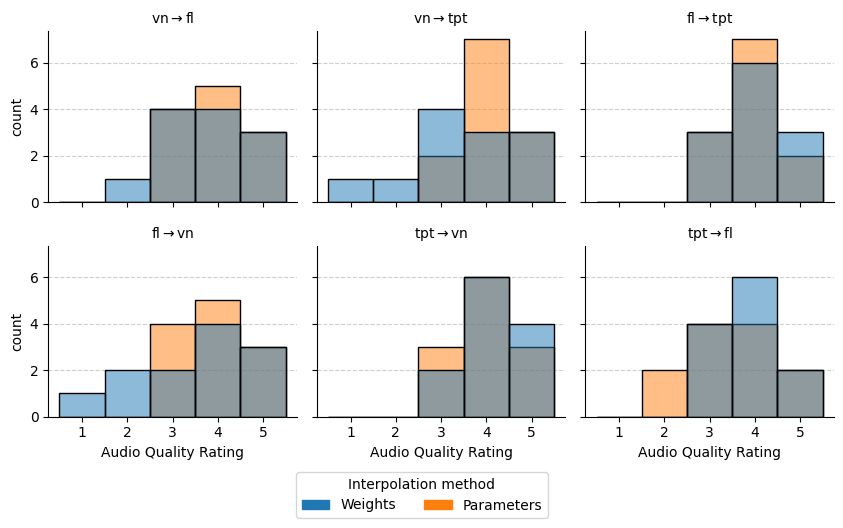

In [11]:
import matplotlib.patches as mpatches

scores = np.sort(df_mos["rating_score"].dropna().unique()).astype(int)
bin_edges = np.arange(scores.min() - 0.5, scores.max() + 1.5, 1)

pair_order = [
    "vn->fl",
    "vn->tpt",
    "fl->tpt",
    "fl->vn",
    "tpt->vn",
    "tpt->fl"
]

g = sns.displot(
    data=df_mos,
    x="rating_score",
    col="pair",
    hue="method",
    col_order=pair_order,
    col_wrap=3,
    kind="hist",
    multiple="layer",
    bins=bin_edges,
    height=2.5,
    aspect=1.0,
    palette={"weights": "tab:blue", "outputs": "tab:orange"},
    alpha=0.5
)

for ax in g.axes.flat:
    ax.set_xticks(scores) 
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)

g.set_axis_labels("Audio Quality Rating", "count")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks(scores)
    ax.set_title(ax.get_title().replace("->", r"$\rightarrow$"), fontsize=10)

# remove the default seaborn legend
if g._legend is not None:
    g._legend.remove()

# custom legend
handles = [
    mpatches.Patch(color="tab:blue", label="Weights"),
    mpatches.Patch(color="tab:orange", label="Parameters")
]

g.figure.legend(
    handles=handles,
    title="Interpolation method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10), 
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [12]:
MOS_result_per_ordered_pair = df_mos.groupby(["pair", "method"])["rating_score"].agg(["mean", "std", "count"]).reset_index()
MOS_result_per_ordered_pair

,pair,method,mean,std,count
0,fl->tpt,outputs,3.916667,0.668558,12
1,fl->tpt,weights,4.000000,0.738549,12
2,fl->vn,outputs,3.916667,0.792961,12
3,fl->vn,weights,3.500000,1.314257,12
4,tpt->fl,outputs,3.500000,1.000000,12
5,tpt->fl,weights,3.833333,0.717741,12
6,tpt->vn,outputs,4.000000,0.738549,12
7,tpt->vn,weights,4.166667,0.717741,12
8,vn->fl,outputs,3.916667,0.792961,12
9,vn->fl,weights,3.750000,0.965307,12


In [13]:
df_mos["unordered_pair"].unique()

<StringArray>
['tpt-vn', 'fl-vn', 'fl-tpt']
Length: 3, dtype: str

In [14]:
df_mos.columns

Index(['pair', 'method', 'unordered_pair', 'session_uuid', 'trial_id',
       'rating_score'],
      dtype='str')

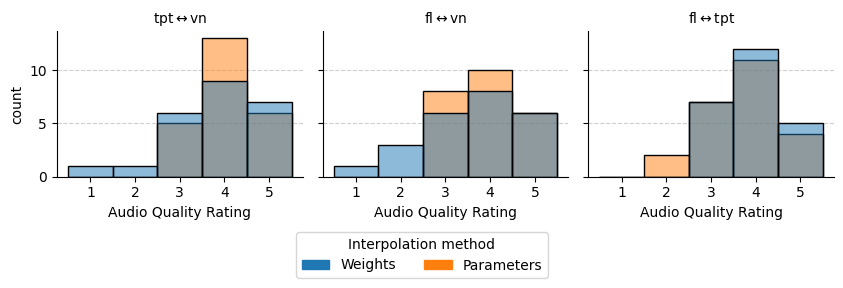

In [15]:
import matplotlib.patches as mpatches

scores = np.sort(df_mos["rating_score"].dropna().unique()).astype(int)
bin_edges = np.arange(scores.min() - 0.5, scores.max() + 1.5, 1)

pair_order = [
    "tpt-vn",
    "fl-vn",
    "fl-tpt",
]

g = sns.displot(
    data=df_mos,
    x="rating_score",
    col="unordered_pair",
    col_order=pair_order,
    hue="method",
    col_wrap=3,
    kind="hist",
    multiple="layer",
    bins=bin_edges,
    height=2.5,
    aspect=1.0,
    palette={"weights": "tab:blue", "outputs": "tab:orange"},
    alpha=0.5
)

for ax in g.axes.flat:
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)

g.set_axis_labels("Audio Quality Rating", "count")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks(scores)
    ax.set_title(ax.get_title().replace("-", r"$\leftrightarrow$"), fontsize=10)
    ax.set_axisbelow(True)

# remove the default seaborn legend
if g._legend is not None:
    g._legend.remove()

# custom legend
handles = [
    mpatches.Patch(color="tab:blue", label="Weights"),
    mpatches.Patch(color="tab:orange", label="Parameters")
]

g.figure.legend(
    handles=handles,
    title="Interpolation method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.2), 
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
MOS_result_per_unordered_pair = df_mos.groupby(["unordered_pair", "method"])["rating_score"].agg(["mean", "std", "count"]).reset_index()
MOS_result_per_unordered_pair

,unordered_pair,method,mean,std,count
0,fl-tpt,outputs,3.708333,0.858673,24
1,fl-tpt,weights,3.916667,0.717282,24
2,fl-vn,outputs,3.916667,0.775532,24
3,fl-vn,weights,3.625000,1.134920,24
4,tpt-vn,outputs,4.041667,0.690253,24
5,tpt-vn,weights,3.833333,1.049500,24


In [17]:
df_mos["unordered_pair"].unique()

<StringArray>
['tpt-vn', 'fl-vn', 'fl-tpt']
Length: 3, dtype: str

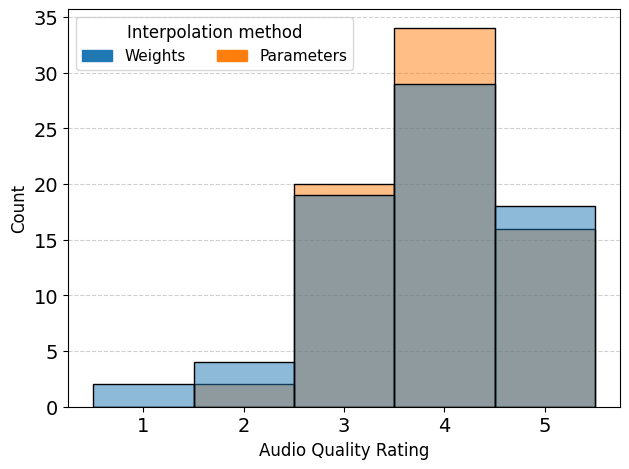

In [18]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

scores = np.sort(df_mos["rating_score"].dropna().unique()).astype(int)
bin_edges = np.arange(scores.min() - 0.5, scores.max() + 1.5, 1)

ax = sns.histplot(
    data=df_mos,
    x="rating_score",
    hue="method",
    multiple="layer",
    bins=bin_edges,
    palette={"weights": "tab:blue", "outputs": "tab:orange"},
    alpha=0.5
)

handles = [
    mpatches.Patch(color="tab:blue", label="Weights"),
    mpatches.Patch(color="tab:orange", label="Parameters")
]

ax.legend(
    handles=handles,
    title="Interpolation method",
    loc="upper left",
    ncol=2,
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

ax.set_xticks(scores)
ax.tick_params(axis="both", labelsize=14)
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)
ax.set_xlabel("Audio Quality Rating", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

In [19]:
MOS_result_per_method = df_mos.groupby("method")["rating_score"].agg(["mean", "std", "count"]).reset_index()
MOS_result_per_method


,method,mean,std,count
0,outputs,3.888889,0.779230,72
1,weights,3.791667,0.977745,72


### Repeated Measures Anova

In [20]:
aov = pg.rm_anova(
    data=df_mos,
    dv='rating_score',
    within=['method', 'pair'],
    subject='session_uuid',
    detailed=True,
    correction=True
)
print(aov)

          Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         method  0.340278      1     11  0.340278  0.555098  0.471861   
1           pair  2.951389      5     55  0.590278  1.932617  0.103641   
2  method * pair  3.784722      5     55  0.756944  2.503132  0.041090   

   p_GG_corr       ng2       eps  
0   0.471861  0.003253  1.000000  
1   0.135640  0.027531  0.668691  
2   0.070481  0.035032  0.650475  


In [21]:
for pair_name, group in df_mos.groupby('unordered_pair'):
    aov = pg.rm_anova(
        data=group,
        dv='rating_score',
        within=['method', 'pair'],
        subject='session_uuid',
        detailed=True,
        correction=True
    )
    print(f"Pair: {pair_name}")
    print(aov)

Pair: fl-tpt
          Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         method  0.520833      1     11  0.520833  1.774194  0.209804   
1           pair  1.020833      1     11  1.020833  6.493976  0.027076   
2  method * pair  0.187500      1     11  0.187500  1.320000  0.274961   

   p_GG_corr       ng2  eps  
0   0.209804  0.018532  1.0  
1   0.027076  0.035688  1.0  
2   0.274961  0.006752  1.0  
Pair: fl-vn
          Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         method  1.020833      1     11  1.020833  1.364557  0.267444   
1           pair  0.187500      1     11  0.187500  1.000000  0.338801   
2  method * pair  0.187500      1     11  0.187500  0.673469  0.429271   

   p_GG_corr       ng2  eps  
0   0.267444  0.023146  1.0  
1   0.338801  0.004333  1.0  
2   0.429271  0.004333  1.0  
Pair: tpt-vn
          Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         method  0.520833      1     11  0.520833  1.

In [22]:
for pair_name, group in df_mos.groupby('pair'):

    aov = pg.rm_anova(
        data=group,
        dv='rating_score',
        within='method',
        subject='session_uuid',
        detailed=True,
        correction=True
    )

    print(f"Pair: {pair_name}")
    print(aov)

Pair: fl->tpt
   Source        SS  DF        MS         F     p_unc       ng2  eps
0  method  0.041667   1  0.041667  0.314286  0.586299  0.003802  1.0
1   Error  1.458333  11  0.132576       NaN       NaN       NaN  NaN
Pair: fl->vn
   Source        SS  DF        MS        F     p_unc      ng2  eps
0  method  1.041667   1  1.041667  1.35468  0.269086  0.03864  1.0
1   Error  8.458333  11  0.768939      NaN       NaN      NaN  NaN
Pair: tpt->fl
   Source        SS  DF        MS    F     p_unc       ng2  eps
0  method  0.666667   1  0.666667  2.2  0.166087  0.038462  1.0
1   Error  3.333333  11  0.303030  NaN       NaN       NaN  NaN
Pair: tpt->vn
   Source        SS  DF        MS    F     p_unc       ng2  eps
0  method  0.166667   1  0.166667  1.0  0.338801  0.014085  1.0
1   Error  1.833333  11  0.166667  NaN       NaN       NaN  NaN
Pair: vn->fl
   Source        SS  DF        MS         F     p_unc       ng2  eps
0  method  0.166667   1  0.166667  0.647059  0.438206  0.009615  1.0
1 

In [23]:
pairwise = pg.pairwise_tests(
    data=df_mos,
    dv='rating_score',
    within=['pair', 'method'],
    subject='session_uuid',
    padjust='holm'
)

print(pairwise)

         Contrast     pair        A        B Paired Parametric         T  \
0            pair        -  fl->tpt   fl->vn   True       True  1.393261   
1            pair        -  fl->tpt  tpt->fl   True       True  2.548328   
2            pair        -  fl->tpt  tpt->vn   True       True -1.148913   
3            pair        -  fl->tpt   vn->fl   True       True  0.897150   
4            pair        -  fl->tpt  vn->tpt   True       True  1.076055   
5            pair        -   fl->vn  tpt->fl   True       True  0.200000   
6            pair        -   fl->vn  tpt->vn   True       True -1.914854   
7            pair        -   fl->vn   vn->fl   True       True -1.000000   
8            pair        -   fl->vn  vn->tpt   True       True -0.483779   
9            pair        -  tpt->fl  tpt->vn   True       True -2.803060   
10           pair        -  tpt->fl   vn->fl   True       True -1.172604   
11           pair        -  tpt->fl  vn->tpt   True       True -0.820652   
12          

# Timbre

In [24]:
df_timbre = df[df["rating_stimulus"] != "MOS"]

In [25]:
df_timbre["alpha"] = df_timbre["rating_stimulus"].str.extract(r"alpha_([0-9.]+)", expand=False).astype(float)

In [26]:
len(df) - len(df_timbre)

144

In [27]:
len(df_timbre[(df_timbre["rating_stimulus"]=="reference_0")])

156

In [68]:
df_timbre

,session_test_id,age,gender,gender_self_describe,years_musical_experience,musical_occupation,musical_occupation_self_describe,comment,session_uuid,trial_id,rating_stimulus,rating_score,rating_time,rating_comment,pair,method,unordered_pair,alpha
0,morphing_example,35-44,female,NaN,30,music_producer,Electronic music producer and sound designer,NaN,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_vn_tpt,reference_0,0,166522,NaN,vn->tpt,outputs,tpt-vn,NaN
1,morphing_example,35-44,female,NaN,30,music_producer,Electronic music producer and sound designer,NaN,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_vn_tpt,C3,76,166522,NaN,vn->tpt,outputs,tpt-vn,NaN
2,morphing_example,35-44,female,NaN,30,music_producer,Electronic music producer and sound designer,NaN,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_vn_tpt,C2,49,166522,NaN,vn->tpt,outputs,tpt-vn,NaN
3,morphing_example,35-44,female,NaN,30,music_producer,Electronic music producer and sound designer,NaN,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_vn_tpt,reference_100,99,166522,NaN,vn->tpt,outputs,tpt-vn,NaN
4,morphing_example,35-44,female,NaN,30,music_producer,Electronic music producer and sound designer,NaN,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_vn_tpt,C1,25,166522,NaN,vn->tpt,outputs,tpt-vn,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,morphing_example,25-34,male,NaN,15,other,Audio processing teacher,NaN,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,interpolate_outputs_vn_fl,C1,19,181212,NaN,vn->fl,outputs,fl-vn,NaN
991,morphing_example,25-34,male,NaN,15,other,Audio processing teacher,NaN,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,interpolate_outputs_vn_fl,reference_100,100,181212,NaN,vn->fl,outputs,fl-vn,NaN
992,morphing_example,25-34,male,NaN,15,other,Audio processing teacher,NaN,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,interpolate_outputs_vn_fl,reference_0,0,181212,NaN,vn->fl,outputs,fl-vn,NaN
993,morphing_example,25-34,male,NaN,15,other,Audio processing teacher,NaN,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,interpolate_outputs_vn_fl,C3,64,181212,NaN,vn->fl,outputs,fl-vn,NaN


In [69]:
df_timbre.groupby("trial_id")["session_uuid"].nunique()

trial_id
interpolate_outputs_fl_tpt    13
interpolate_outputs_fl_vn     13
interpolate_outputs_tpt_fl    13
interpolate_outputs_tpt_vn    13
interpolate_outputs_vn_fl     13
interpolate_outputs_vn_tpt    13
interpolate_weights_fl_tpt    13
interpolate_weights_fl_vn     13
interpolate_weights_tpt_fl    13
interpolate_weights_tpt_vn    13
interpolate_weights_vn_fl     13
interpolate_weights_vn_tpt    13
Name: session_uuid, dtype: int64

### When are the extremes wrong?

In [28]:
df_wrong_0 = df_timbre[(df_timbre["rating_stimulus"]=="reference_0") & (df_timbre["rating_score"] > 20)]
len(df_wrong_0)

29

In [29]:
df_wrong_100 = df_timbre[(df_timbre["rating_stimulus"]=="reference_100") & (df_timbre["rating_score"] < 80)]
len(df_wrong_100)

18

In [30]:
df_both_wr = df_timbre[((df_timbre["rating_stimulus"]=="reference_0") & (df_timbre["rating_score"] > 20)) & ((df_timbre["rating_stimulus"]=="reference_100") & (df_timbre["rating_score"] < 80))]
len(df_both_wr)

0

In [31]:
df_one_wr = df_timbre[((df_timbre["rating_stimulus"]=="reference_0") & (df_timbre["rating_score"] > 20)) | ((df_timbre["rating_stimulus"]=="reference_100") & (df_timbre["rating_score"] < 80))]
len(df_one_wr)

47

In [32]:
df_one_wr[["session_uuid", "trial_id"]].drop_duplicates()

,session_uuid,trial_id
47,696cfac7-4b3e-4701-8229-cada9a2f3f56,interpolate_outputs_tpt_fl
72,94359fbd-8eee-4ac6-af4a-a0e3fff5c48e,interpolate_weights_fl_vn
98,94359fbd-8eee-4ac6-af4a-a0e3fff5c48e,interpolate_outputs_tpt_vn
126,94359fbd-8eee-4ac6-af4a-a0e3fff5c48e,interpolate_weights_vn_tpt
224,2972da2a-7403-4a25-8825-c93f4631bbf8,interpolate_outputs_tpt_vn
232,2972da2a-7403-4a25-8825-c93f4631bbf8,interpolate_weights_tpt_fl
253,2972da2a-7403-4a25-8825-c93f4631bbf8,interpolate_outputs_tpt_fl
274,2972da2a-7403-4a25-8825-c93f4631bbf8,interpolate_outputs_fl_tpt
276,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_fl_tpt
307,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_vn_tpt


In [33]:
df_one_wr.groupby("trial_id")["session_uuid"].nunique()


trial_id
interpolate_outputs_fl_tpt    5
interpolate_outputs_fl_vn     1
interpolate_outputs_tpt_fl    6
interpolate_outputs_tpt_vn    3
interpolate_outputs_vn_fl     3
interpolate_outputs_vn_tpt    1
interpolate_weights_fl_tpt    1
interpolate_weights_fl_vn     3
interpolate_weights_tpt_fl    4
interpolate_weights_tpt_vn    2
interpolate_weights_vn_fl     2
interpolate_weights_vn_tpt    6
Name: session_uuid, dtype: int64

### Is getting the references wrong systematic for some users?

In [34]:
def plot_per_ordered_pair(df):
    palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
    stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

    filt = df[
        df['rating_stimulus'].isin(stimulus_x.keys())
        & df['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
    ].copy()

    filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
    filt['variant'] = filt['trial_id'].str.extract(r"interpolate_(?:weights|outputs)[-_]?(.+)$", expand=False).fillna(filt['trial_id'])
    filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

    g = sns.relplot(
        data=filt, x="expected_x", y="rating_score", hue="method",
        col="variant", col_wrap=3, palette=palette, errorbar="sd",
        marker="o", kind="line", height=3.5, facet_kws={"sharex": True, "sharey": True}
    )

    for ax in g.axes.flat:
        ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="ideal")
        ax.set_xticks(sorted(stimulus_x.values()))

    g.set_axis_labels("expected rating (stimulus position)", "rating_score (mean ± std)")
    g.set_titles("{col_name}")
    g.add_legend(title="method")
    plt.tight_layout()
    plt.show()


In [35]:
df_one_wr[["session_uuid", "trial_id"]].drop_duplicates()["session_uuid"].value_counts()

session_uuid
6b980f92-d2c6-404e-bf27-964e3a3b63ce    11
57945201-861a-46ee-ba6e-a2ce7832bcdd     6
2972da2a-7403-4a25-8825-c93f4631bbf8     4
18643d68-5fb8-4606-9e27-1632cdbdf8f4     4
8f5acd6c-2536-4a43-9a37-1bb248d5f571     4
94359fbd-8eee-4ac6-af4a-a0e3fff5c48e     3
3d1b1edf-ab1b-45c9-a7b2-1c4a842f085c     2
696cfac7-4b3e-4701-8229-cada9a2f3f56     1
ec69a24a-e37e-4380-b937-1cd1c0aafef4     1
3556dfdf-fa41-4239-8058-7009833c9e33     1
Name: count, dtype: int64

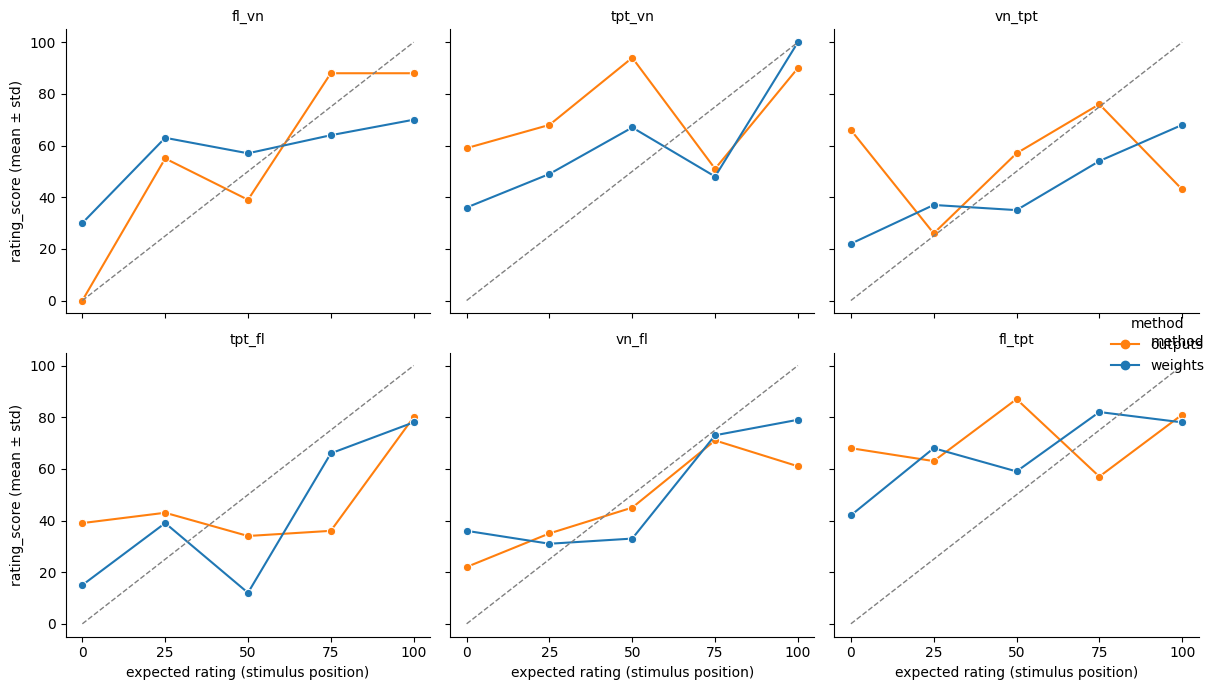

In [36]:
session_id = "6b980f92-d2c6-404e-bf27-964e3a3b63ce"

df_for_session = df_timbre[df_timbre["session_uuid"] == session_id]
plot_per_ordered_pair(df_for_session)

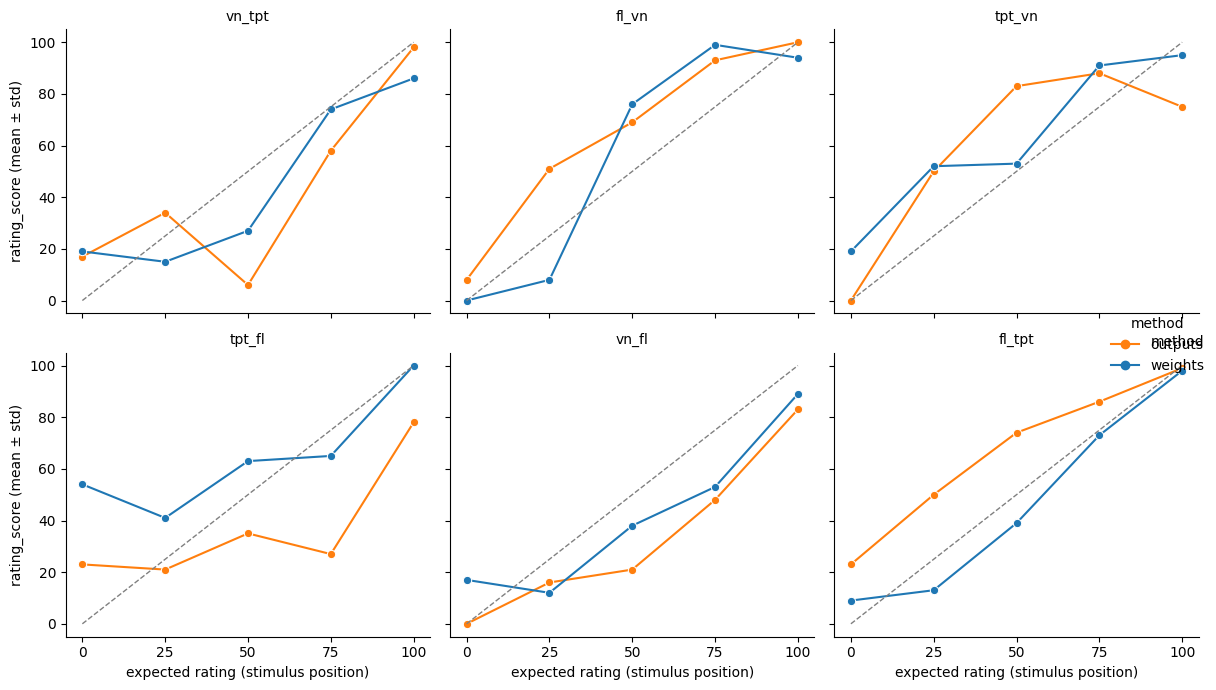

In [37]:
session_id = "2972da2a-7403-4a25-8825-c93f4631bbf8"

df_for_session = df_timbre[df_timbre["session_uuid"] == session_id]
plot_per_ordered_pair(df_for_session)

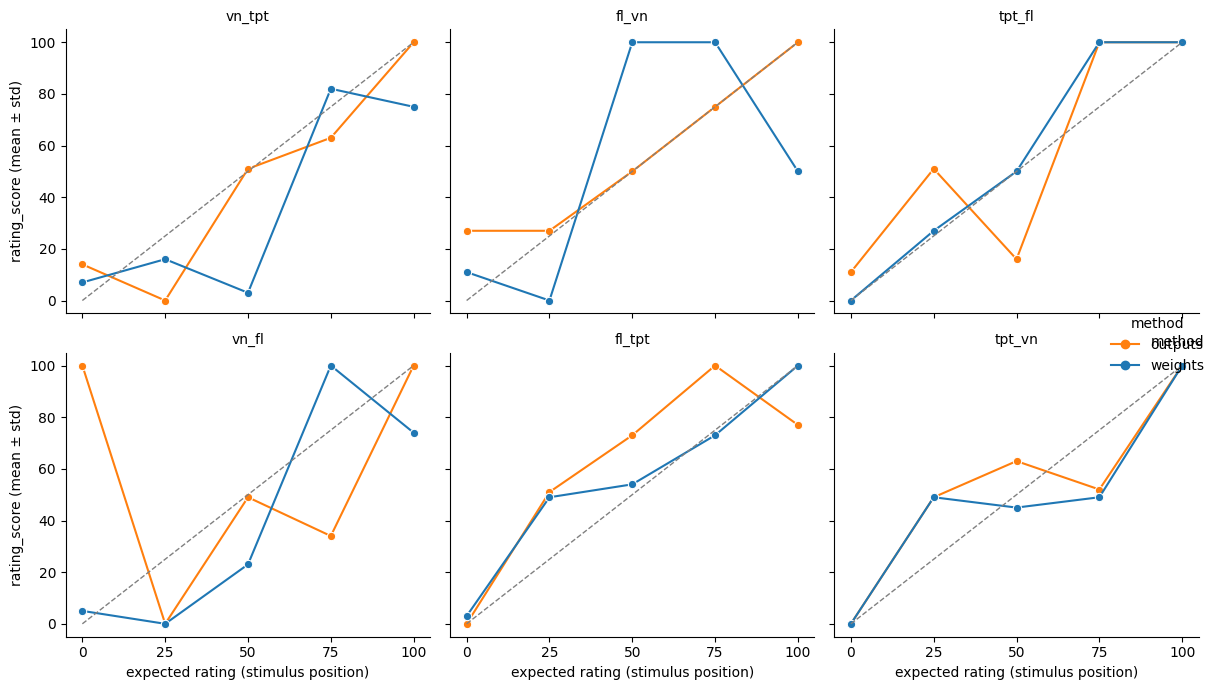

In [38]:
session_id = "57945201-861a-46ee-ba6e-a2ce7832bcdd"

df_for_session = df_timbre[df_timbre["session_uuid"] == session_id]
plot_per_ordered_pair(df_for_session)


In [39]:
df_one_wr[["session_uuid", "trial_id"]].drop_duplicates()["trial_id"].value_counts()

trial_id
interpolate_outputs_tpt_fl    6
interpolate_weights_vn_tpt    6
interpolate_outputs_fl_tpt    5
interpolate_weights_tpt_fl    4
interpolate_weights_fl_vn     3
interpolate_outputs_tpt_vn    3
interpolate_outputs_vn_fl     3
interpolate_weights_tpt_vn    2
interpolate_weights_vn_fl     2
interpolate_outputs_vn_tpt    1
interpolate_weights_fl_tpt    1
interpolate_outputs_fl_vn     1
Name: count, dtype: int64

## Filter

In [40]:
bad_mask = (
    ((df_timbre["rating_stimulus"] == "reference_0") & (df_timbre["rating_score"] > 20))
    | ((df_timbre["rating_stimulus"] == "reference_100") & (df_timbre["rating_score"] < 80))
)

bad_pairs = (
    df_timbre.loc[bad_mask, ["trial_id", "session_uuid"]]
      .drop_duplicates()
)

df_clean = df_timbre[~df_timbre.set_index(["trial_id", "session_uuid"]).index.isin(
    bad_pairs.set_index(["trial_id", "session_uuid"]).index
)]

In [41]:
len(df_timbre) - len(df_clean)

185

In [42]:
df_clean.columns

Index(['session_test_id', 'age', 'gender', 'gender_self_describe',
       'years_musical_experience', 'musical_occupation',
       'musical_occupation_self_describe', 'comment', 'session_uuid',
       'trial_id', 'rating_stimulus', 'rating_score', 'rating_time',
       'rating_comment', 'pair', 'method', 'unordered_pair', 'alpha'],
      dtype='str')

In [43]:
df_clean[["session_uuid", "trial_id", "pair", "method", "unordered_pair"]].drop_duplicates()[["pair", "method"]].value_counts()

pair     method 
vn->tpt  outputs    12
fl->tpt  weights    12
fl->vn   outputs    12
vn->fl   weights    11
tpt->vn  weights    11
         outputs    10
vn->fl   outputs    10
fl->vn   weights    10
tpt->fl  weights     9
fl->tpt  outputs     8
vn->tpt  weights     7
tpt->fl  outputs     7
Name: count, dtype: int64

In [44]:
df_clean[["session_uuid", "trial_id", "pair", "method", "unordered_pair"]].drop_duplicates()[["unordered_pair", "method"]].value_counts()

unordered_pair  method 
tpt-vn          outputs    22
fl-vn           outputs    22
fl-tpt          weights    21
fl-vn           weights    21
tpt-vn          weights    18
fl-tpt          outputs    15
Name: count, dtype: int64

In [45]:
df_clean[["session_uuid", "trial_id", "pair", "method", "unordered_pair"]].drop_duplicates()[["method"]].value_counts()

method 
weights    60
outputs    59
Name: count, dtype: int64

### When is the change not monotone?

In [46]:
def get_order_not_the_same(df):
    stim_order = ["reference_0", "C1", "C2", "C3", "reference_100"]

    # keep only relevant stimuli
    df_check = df[df["rating_stimulus"].isin(stim_order)].copy()

    # one row per (session_uuid, trial_id), one column per stimulus
    # if duplicates existed (they don't here), mean is used
    wide = (
        df_check.pivot_table(
            index=["session_uuid", "trial_id"],
            columns="rating_stimulus",
            values="rating_score",
            aggfunc="mean"
        )
        .reindex(columns=stim_order)
    )

    # flags
    wide["has_all_5"] = wide.notna().all(axis=1)
    wide["in_order_non_decreasing"] = wide[stim_order].apply(
        lambda s: s.is_monotonic_increasing if s.notna().all() else False,
        axis=1
    )
    wide["in_order_strict"] = wide[stim_order].apply(
        lambda s: (np.diff(s.to_numpy()) > 0).all() if s.notna().all() else False,
        axis=1
    )

    order_check = wide.reset_index()
    order_check.head()

    # pairs that fail non-decreasing order
    failed = order_check[order_check["has_all_5"] & ~order_check["in_order_non_decreasing"]]
    return failed


In [47]:
non_monotone_all = get_order_not_the_same(df_clean)
non_monotone_all.head()

rating_stimulus,session_uuid,trial_id,reference_0,C1,C2,C3,reference_100,has_all_5,in_order_non_decreasing,in_order_strict
0,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_fl_vn,0.0,50.0,39.0,71.0,100.0,True,False,False
1,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_tpt_vn,0.0,41.0,75.0,52.0,100.0,True,False,False
3,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_fl_tpt,1.0,39.0,75.0,50.0,100.0,True,False,False
5,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_tpt_fl,0.0,30.0,91.0,81.0,100.0,True,False,False
7,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_vn_fl,0.0,47.0,57.0,25.0,85.0,True,False,False


In [48]:
non_monotone_all["pair"] = non_monotone_all["trial_id"].apply(lambda x: "->".join(x.split("_")[2:4]))
non_monotone_all["method"] = non_monotone_all["trial_id"].apply(lambda x: x.split("_")[1])
non_monotone_all["unordered_pair"] = non_monotone_all["pair"].apply(lambda x: "-".join(sorted(x.split("->"))))

In [49]:
non_monotone_per_directed_pair = non_monotone_all.groupby(["pair", "method"]).size().reset_index(name="count")
non_monotone_per_directed_pair

,pair,method,count
0,fl->tpt,outputs,3
1,fl->tpt,weights,6
2,fl->vn,outputs,4
3,fl->vn,weights,2
4,tpt->fl,outputs,5
5,tpt->fl,weights,7
6,tpt->vn,outputs,5
7,tpt->vn,weights,3
8,vn->fl,outputs,3
9,vn->fl,weights,3


In [50]:
non_monotone_per_unordered_pair = non_monotone_all.groupby(["method", "unordered_pair"]).size().reset_index(name="count")
non_monotone_per_unordered_pair

,method,unordered_pair,count
0,outputs,fl-tpt,8
1,outputs,fl-vn,7
2,outputs,tpt-vn,11
3,weights,fl-tpt,13
4,weights,fl-vn,5
5,weights,tpt-vn,5


In [51]:
non_monotone_per_method = non_monotone_all.groupby(["method"]).size().reset_index(name="count")
non_monotone_per_method

,method,count
0,outputs,26
1,weights,23


In [52]:
non_monotone_all["session_uuid"].value_counts()

session_uuid
3d1b1edf-ab1b-45c9-a7b2-1c4a842f085c    6
ec69a24a-e37e-4380-b937-1cd1c0aafef4    6
18643d68-5fb8-4606-9e27-1632cdbdf8f4    5
94359fbd-8eee-4ac6-af4a-a0e3fff5c48e    5
2972da2a-7403-4a25-8825-c93f4631bbf8    4
57945201-861a-46ee-ba6e-a2ce7832bcdd    4
8f5acd6c-2536-4a43-9a37-1bb248d5f571    4
696cfac7-4b3e-4701-8229-cada9a2f3f56    3
a6fcb532-5695-48e9-8ce1-6d9a0795faeb    3
be207b14-f65a-4609-acac-7142b5b1b443    3
d8310ea2-d7d9-49d9-9e40-affc3f8a261a    3
3556dfdf-fa41-4239-8058-7009833c9e33    2
6b980f92-d2c6-404e-bf27-964e3a3b63ce    1
Name: count, dtype: int64

In [65]:
non_monotone_all_no_filtered = get_order_not_the_same(df_timbre)
non_monotone_all_no_filtered["pair"] = non_monotone_all_no_filtered["trial_id"].apply(lambda x: "->".join(x.split("_")[2:4]))
non_monotone_all_no_filtered["method"] = non_monotone_all_no_filtered["trial_id"].apply(lambda x: x.split("_")[1])
non_monotone_all_no_filtered["unordered_pair"] = non_monotone_all_no_filtered["pair"].apply(lambda x: "-".join(sorted(x.split("->"))))

In [66]:
non_monotone_per_directed_pair = non_monotone_all.groupby(["pair", "method"]).size().reset_index(name="count")
non_monotone_per_directed_pair

,pair,method,count
0,fl->tpt,outputs,3
1,fl->tpt,weights,6
2,fl->vn,outputs,4
3,fl->vn,weights,2
4,tpt->fl,outputs,5
5,tpt->fl,weights,7
6,tpt->vn,outputs,5
7,tpt->vn,weights,3
8,vn->fl,outputs,3
9,vn->fl,weights,3


###  Are intermediate stimuli perceived in the middle?

In [53]:
def get_stimuli_in_the_middle_in_middle(df):
    stim_order = ["reference_0", "C1", "C2", "C3", "reference_100"]

    # keep only relevant stimuli
    df_check = df[df["rating_stimulus"].isin(stim_order)].copy()

    # one row per (session_uuid, trial_id), one column per stimulus
    # if duplicates existed (they don't here), mean is used
    wide = (
        df_check.pivot_table(
            index=["session_uuid", "trial_id"],
            columns="rating_stimulus",
            values="rating_score",
            aggfunc="mean"
        )
        .reindex(columns=stim_order)
    )
    
    # flags
    wide["has_all_5"] = wide.notna().all(axis=1)
    wide["middle_stimuli_in_middle"] = (
    (wide["C1"] > wide["reference_0"]) &
    (wide["C2"] > wide["reference_0"]) &
    (wide["C3"] > wide["reference_0"]) &
    (wide["C1"] < wide["reference_100"]) &
    (wide["C2"] < wide["reference_100"]) &
    (wide["C3"] < wide["reference_100"])
    )  

    order_check = wide.reset_index()
    order_check.head()

    # pairs that fail non-decreasing order
    failed = order_check[order_check["has_all_5"] & order_check["middle_stimuli_in_middle"]]
    return failed


In [54]:
df_in_middle = get_stimuli_in_the_middle_in_middle(df_clean)
df_in_middle.head()

rating_stimulus,session_uuid,trial_id,reference_0,C1,C2,C3,reference_100,has_all_5,middle_stimuli_in_middle
0,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_fl_vn,0.0,50.0,39.0,71.0,100.0,True,True
1,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_tpt_vn,0.0,41.0,75.0,52.0,100.0,True,True
2,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_outputs_vn_tpt,2.0,11.0,27.0,75.0,88.0,True,True
3,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_fl_tpt,1.0,39.0,75.0,50.0,100.0,True,True
4,18643d68-5fb8-4606-9e27-1632cdbdf8f4,interpolate_weights_fl_vn,0.0,28.0,51.0,88.0,100.0,True,True


In [55]:
df_in_middle["pair"] = df_in_middle["trial_id"].apply(lambda x: "->".join(x.split("_")[2:4]))
df_in_middle["method"] = df_in_middle["trial_id"].apply(lambda x: x.split("_")[1])
df_in_middle["unordered_pair"] = df_in_middle["pair"].apply(lambda x: "-".join(sorted(x.split("->"))))

In [56]:
df_in_middle.groupby(["pair", "method"]).size().reset_index(name="count")

,pair,method,count
0,fl->tpt,outputs,8
1,fl->tpt,weights,12
2,fl->vn,outputs,11
3,fl->vn,weights,9
4,tpt->fl,outputs,4
5,tpt->fl,weights,8
6,tpt->vn,outputs,10
7,tpt->vn,weights,10
8,vn->fl,outputs,10
9,vn->fl,weights,9


In [57]:
df_in_middle.groupby(["unordered_pair", "method"]).size().reset_index(name="count")

,unordered_pair,method,count
0,fl-tpt,outputs,12
1,fl-tpt,weights,20
2,fl-vn,outputs,21
3,fl-vn,weights,18
4,tpt-vn,outputs,18
5,tpt-vn,weights,16


In [62]:
df_in_middle_all = get_stimuli_in_the_middle_in_middle(df_timbre)
df_in_middle_all.head()
df_in_middle_all["pair"] = df_in_middle_all["trial_id"].apply(lambda x: "->".join(x.split("_")[2:4]))
df_in_middle_all["method"] = df_in_middle_all["trial_id"].apply(lambda x: x.split("_")[1])
df_in_middle_all["unordered_pair"] = df_in_middle_all["pair"].apply(lambda x: "-".join(sorted(x.split("->"))))

In [63]:
df_in_middle_all.groupby(["pair", "method"]).size().reset_index(name="count")

,pair,method,count
0,fl->tpt,outputs,9
1,fl->tpt,weights,12
2,fl->vn,outputs,11
3,fl->vn,weights,11
4,tpt->fl,outputs,4
5,tpt->fl,weights,8
6,tpt->vn,outputs,10
7,tpt->vn,weights,11
8,vn->fl,outputs,10
9,vn->fl,weights,9


In [64]:
df_in_middle_all.groupby(["unordered_pair", "method"]).size().reset_index(name="count")

,unordered_pair,method,count
0,fl-tpt,outputs,13
1,fl-tpt,weights,20
2,fl-vn,outputs,21
3,fl-vn,weights,20
4,tpt-vn,outputs,18
5,tpt-vn,weights,19


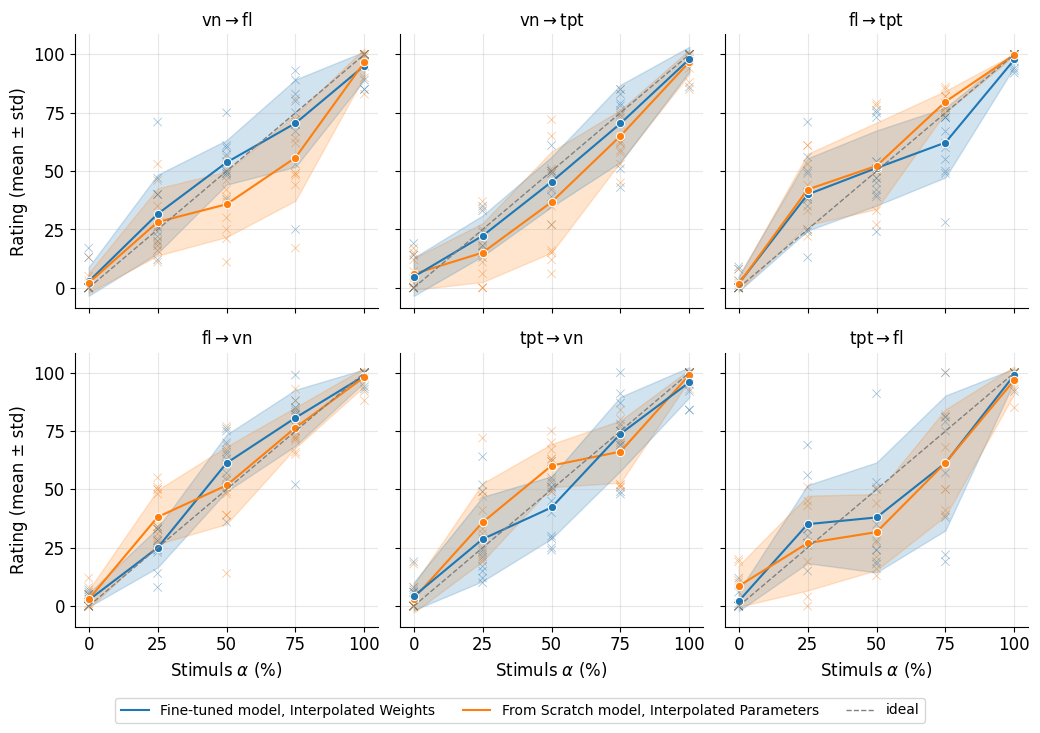

In [58]:
import numpy as np
from matplotlib.lines import Line2D

pair_order = [
    "vn_fl",
    "vn_tpt",
    "fl_tpt",
    "fl_vn",
    "tpt_vn",
    "tpt_fl"
]

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df_clean[
    df_clean['rating_stimulus'].isin(stimulus_x.keys())
    & df_clean['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
].copy()

filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
filt['variant'] = filt['trial_id'].str.extract(r"interpolate_(?:weights|outputs)[-_]?(.+)$", expand=False).fillna(filt['trial_id'])
filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

g = sns.relplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    col="variant", col_order=pair_order, col_wrap=3, palette=palette,
    kind="scatter", marker="x", alpha=0.5, height=3.5,
    legend=False
)

g.map_dataframe(
    sns.lineplot, x="expected_x", y="rating_score", hue="method",
    marker="o", palette=palette, errorbar="sd", legend=False
)

for ax in g.axes.flat:
    ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="ideal")
    ax.set_xticks(sorted(stimulus_x.values()))
    ax.set_yticks(sorted(stimulus_x.values()))
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.3)

g.set_axis_labels(r"Stimuls $\alpha$ (%)", "Rating (mean ± std)", fontsize=12)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_title(ax.get_title().replace("_", r"$\rightarrow$"), fontsize=12)

legend_handles = [
    Line2D([0], [0], color=palette["weights"], label="Fine-tuned model, Interpolated Weights"),
    Line2D([0], [0], color=palette["outputs"], label="From Scratch model, Interpolated Parameters"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1, label="ideal"),
]

g.figure.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=10
)

plt.tight_layout()
plt.show()


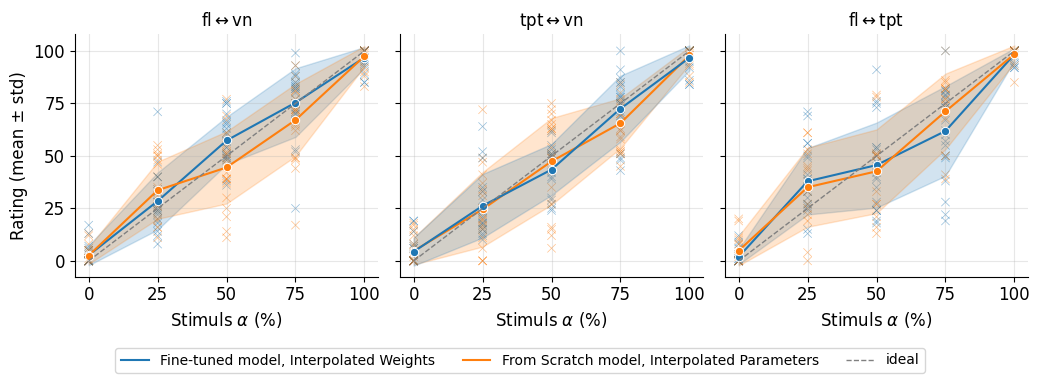

In [59]:
import numpy as np

pair_order = [
    "fl-vn",
    "tpt-vn",
    "fl-tpt"
]

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df_clean[
    df_clean["rating_stimulus"].isin(stimulus_x.keys())
    & df_clean["trial_id"].str.contains(r"interpolate_(?:weights|outputs)", na=False)
].copy()

filt["method"] = np.where(
    filt["trial_id"].str.contains("interpolate_weights", na=False), "weights", "outputs"
)
filt["expected_x"] = filt["rating_stimulus"].map(stimulus_x)

# extract ordered pair from trial_id, then convert to unordered pair
pair_tokens = filt["trial_id"].str.extract(
    r"interpolate_(?:weights|outputs)[-_]?([A-Za-z0-9]+)[-_]([A-Za-z0-9]+)$"
)
filt["unordered_pair"] = pair_tokens.apply(lambda r: "-".join(sorted([r[0], r[1]])), axis=1)

g = sns.relplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    col="unordered_pair", col_order=pair_order, col_wrap=3, palette=palette, marker="x", 
    alpha=0.5, height=3.5, legend=False
)

g.map_dataframe(
    sns.lineplot, x="expected_x", y="rating_score", hue="method",
    marker="o", palette=palette, errorbar="sd", legend=False
)

g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="ideal")
    ax.set_xticks(sorted(stimulus_x.values()))
    ax.set_yticks(sorted(stimulus_x.values()))
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.3)

g.set_axis_labels(r"Stimuls $\alpha$ (%)", "Rating (mean ± std)", fontsize=12)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_title(ax.get_title().replace("-", r"$\leftrightarrow$"), fontsize=12)

legend_handles = [
    Line2D([0], [0], color=palette["weights"], label="Fine-tuned model, Interpolated Weights"),
    Line2D([0], [0], color=palette["outputs"], label="From Scratch model, Interpolated Parameters"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1, label="ideal"),
]

g.figure.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=10
)

plt.tight_layout()
plt.show()


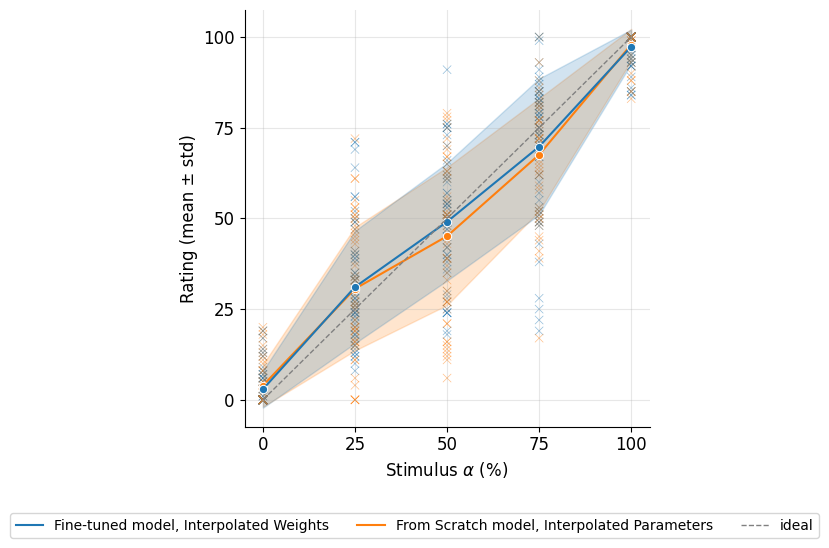

In [60]:
import numpy as np

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df_clean[
    df_clean["rating_stimulus"].isin(stimulus_x.keys())
    & df_clean["trial_id"].str.contains(r"interpolate_(?:weights|outputs)", na=False)
].copy()

filt["method"] = np.where(
    filt["trial_id"].str.contains("interpolate_weights", na=False), "weights", "outputs"
)
filt["expected_x"] = filt["rating_stimulus"].map(stimulus_x)

g = sns.relplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    palette=palette, marker="x", 
    alpha=0.5, legend=False
)

g.map_dataframe(
    sns.lineplot, x="expected_x", y="rating_score", hue="method",
    marker="o", palette=palette, errorbar="sd", legend=False
)

g.axes[0, 0].plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1)
g.axes[0, 0].set_xticks(sorted(stimulus_x.values()))
g.axes[0, 0].set_yticks(sorted(stimulus_x.values()))
g.axes[0, 0].tick_params(axis="both", labelsize=12)
g.axes[0, 0].grid(alpha=0.3)
g.axes[0, 0].set_xlabel(r"Stimulus $\alpha$ (%)", fontsize=12)
g.axes[0, 0].set_ylabel("Rating (mean ± std)", fontsize=12)

legend_handles = [
    Line2D([0], [0], color=palette["weights"], label="Fine-tuned model, Interpolated Weights"),
    Line2D([0], [0], color=palette["outputs"], label="From Scratch model, Interpolated Parameters"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1, label="ideal"),
]

g.figure.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=10
)
plt.tight_layout()
plt.show()


### Spearman rank

In [61]:
filt = df_timbre[
    df_timbre['rating_stimulus'].isin(stimulus_x.keys())
    & df_timbre['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
].copy()

filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
filt['variant'] = filt['trial_id'].str.extract(r"interpolate_(?:weights|outputs)[-_]?(.+)$", expand=False).fillna(filt['trial_id'])
filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

filt[["session_uuid","variant","method","expected_x","rating_score"]]

,session_uuid,variant,method,expected_x,rating_score
0,696cfac7-4b3e-4701-8229-cada9a2f3f56,vn_tpt,outputs,0,0
1,696cfac7-4b3e-4701-8229-cada9a2f3f56,vn_tpt,outputs,75,76
2,696cfac7-4b3e-4701-8229-cada9a2f3f56,vn_tpt,outputs,50,49
3,696cfac7-4b3e-4701-8229-cada9a2f3f56,vn_tpt,outputs,100,99
4,696cfac7-4b3e-4701-8229-cada9a2f3f56,vn_tpt,outputs,25,25
...,...,...,...,...,...
990,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,vn_fl,outputs,25,19
991,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,vn_fl,outputs,100,100
992,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,vn_fl,outputs,0,0
993,d8310ea2-d7d9-49d9-9e40-affc3f8a261a,vn_fl,outputs,75,64
